# 🏠 UrbanNest Analytics - European Housing Intelligence
## Notebook 4: Regression Analysis
**Dataset:** Italian Rental Listings (Cleaned)
**Analyst:** Sahil Changotra
**Method:** sklearn, statsmodels, matplotlib, seaborn

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import root_mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor


# plot style
sns.set_theme(style = 'whitegrid', palette = 'muted')
plt.rcParams['figure.figsize'] = (10,5)

In [54]:
df = pd.read_csv('../data/ha_data_clean.csv')

In [55]:
df.head()

,city,category,country_code,created_at,price,furnished,total_size,registration_possible,washing_machine,tv,balcony,garden,terrace,is_price_outlier
0,Trento,Shared Room,it,2016-03-12 12:31:31,190.0,yes,NaN,NaN,no,yes,no,no,no,False
1,Milan,Apartment,it,2019-11-14 14:48:10,3200.0,yes,50.0,yes,yes,yes,NaN,no,NaN,True
2,Milan,Shared Room,it,2019-10-07 10:08:21,660.0,yes,180.0,NaN,yes,NaN,NaN,NaN,NaN,False
3,Pisa,Shared Room,it,2017-07-05 11:41:57,245.0,yes,140.0,no,yes,no,NaN,no,NaN,False
4,Bologna,Private Room,it,2017-11-16 08:55:46,500.0,yes,18.0,NaN,yes,no,NaN,NaN,NaN,False


In [56]:
# Quick check
print(f"Shape:{df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Shape:(8874, 14)

Column dtypes:
city                      object
category                  object
country_code              object
created_at                object
price                    float64
furnished                 object
total_size               float64
registration_possible     object
washing_machine           object
tv                        object
balcony                   object
garden                    object
terrace                   object
is_price_outlier            bool
dtype: object

First 3 rows:
     city     category country_code           created_at   price furnished  \
0  Trento  Shared Room           it  2016-03-12 12:31:31   190.0       yes   
1   Milan    Apartment           it  2019-11-14 14:48:10  3200.0       yes   
2   Milan  Shared Room           it  2019-10-07 10:08:21   660.0       yes   

   total_size registration_possible washing_machine   tv balcony garden  \
0         NaN                   NaN              no  yes      no     no   
1        50.0

In [57]:
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Missing values:
furnished                3330
total_size               4682
registration_possible    4732
washing_machine          1682
tv                       2755
balcony                  8443
garden                   4685
terrace                  8206
dtype: int64


#### Step 1: Clean and prepare

In [58]:
binary_cols = ['furnished', 'registration_possible', 'washing_machine', 
               'tv', 'balcony', 'garden', 'terrace']

for cols in binary_cols:
    print(f"{col}: {df[df['is_price_outlier']==False][col].value_counts(dropna=False).to_dict()}")               

tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
tv: {'yes': 3075, nan: 2665, 'no': 1949}


In [59]:
binary_cols = ['furnished', 'registration_possible', 'washing_machine', 
               'tv', 'balcony', 'garden', 'terrace']

for cols in binary_cols:
    counts = df[df['is_price_outlier']==False][col].value_counts(dropna=False).to_dict()
print(f"{col}: {counts}")                   

tv: {'yes': 3075, nan: 2665, 'no': 1949}


In [60]:
df_clean = df[df['is_price_outlier']==False].copy()

print("furnished:", df_clean['furnished'].value_counts(dropna=False).to_dict())
print("registration_possible:", df_clean['registration_possible'].value_counts(dropna=False).to_dict())
print("washing_machine:", df_clean['washing_machine'].value_counts(dropna=False).to_dict())
print("tv:", df_clean['tv'].value_counts(dropna=False).to_dict())
print("balcony:", df_clean['balcony'].value_counts(dropna=False).to_dict())
print("garden:", df_clean['garden'].value_counts(dropna=False).to_dict())
print("terrace:", df_clean['terrace'].value_counts(dropna=False).to_dict())

furnished: {'yes': 3980, nan: 2915, 'no': 794}
registration_possible: {nan: 4278, 'yes': 2830, 'no': 581}
washing_machine: {'yes': 5787, nan: 1639, 'no': 263}
tv: {'yes': 3075, nan: 2665, 'no': 1949}
balcony: {nan: 7261, 'no': 428}
garden: {nan: 4088, 'no': 3601}
terrace: {nan: 7023, 'no': 666}


In [61]:
# ── Data Preparation v2 ───────────────────────────────────────────
df_model = df[df['is_price_outlier'] == False].copy()
print(f"Rows after removing outliers: {len(df_model)}")

# Drop useless columns
drop_cols = ['country_code', 'created_at', 'is_price_outlier',
             'balcony', 'garden', 'terrace', 'registration_possible']
df_model = df_model.drop(columns=drop_cols)

# Encode binary cols — fill NaN with 0 (unknown = assume no)
binary_cols = ['furnished', 'washing_machine', 'tv']
for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0}).fillna(0)

# One-hot encode city and category
df_model = pd.get_dummies(df_model, columns=['city', 'category'], drop_first=True)

# Drop remaining nulls (total_size nulls if any)
df_model = df_model.dropna()

print(f"Final model dataset shape: {df_model.shape}")
print(f"Null values remaining: {df_model.isnull().sum().sum()}")

Rows after removing outliers: 7689
Final model dataset shape: (3405, 37)
Null values remaining: 0


#### Step 2: Simple Linear Regression: price ~ total_size

In [62]:
# ── Simple Linear Regression: price ~ total_size ──────────────────

X_simple = df_model[['total_size']]
y = df_model['price']

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y , test_size=0.2, random_state=42)

# Fit model
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# Predictions
y_pred_simple = lr_simple.predict(X_test)

# Metrics
r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = mean_squared_error(y_test, y_pred_simple) ** 0.5

print(f" Simple Linear Regression: price ~ total_size")
print(f"Coefficient (total_size): {lr_simple.coef_[0]:.4f}")
print(f"Intercept: {lr_simple.intercept_:.4f}")
print(f"R-squared:                {r2_simple:.4f}")
print(f"RMSE:                     {rmse_simple:.4f}")
print(f"\nInterpretation: Every 1 sqm increase in size → price changes by €{lr_simple.coef_[0]:.2f}/month")

 Simple Linear Regression: price ~ total_size
Coefficient (total_size): -0.3862
Intercept: 536.1155
R-squared:                0.0131
RMSE:                     227.6452

Interpretation: Every 1 sqm increase in size → price changes by €-0.39/month


#### Step 3 - Plot the regression line:

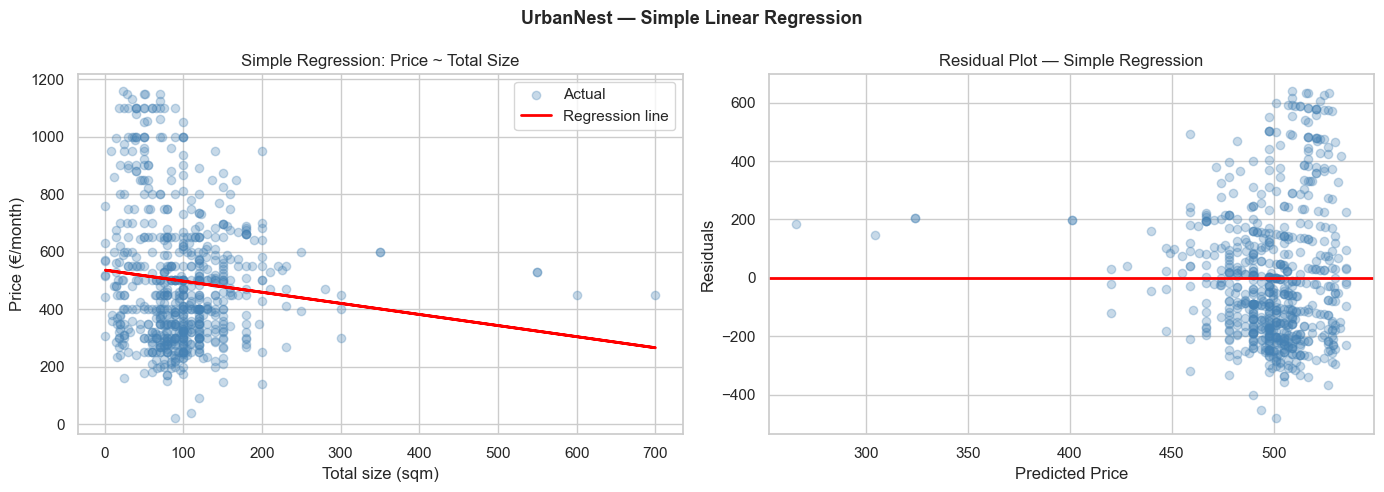

In [63]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# plot 1 - Scatter + regression line

axes[0].scatter(X_test,y_test, alpha = 0.3, color='steelblue',label='Actual')
axes[0].plot(X_test,y_pred_simple, color='red',linewidth=2,label='Regression line')
axes[0].set_xlabel('Total size (sqm)')
axes[0].set_ylabel('Price (€/month)')
axes[0].set_title('Simple Regression: Price ~ Total Size')
axes[0].legend()

# plot 2 - Residuals
residuals  = y_test - y_pred_simple
axes[1].scatter(y_pred_simple, residuals,alpha=0.3,color='steelblue')
axes[1].axhline(y=0, color='red', linewidth=2)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot — Simple Regression')

plt.suptitle('UrbanNest — Simple Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/nb4_simple_regression.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
print("── Simple Regression Interpretation ──────────────────")
print(f"R² = {r2_simple:.4f} → total_size explains only {r2_simple*100:.1f}% of price variance")
print(f"RMSE = €{rmse_simple:.2f} → avg prediction error of €{rmse_simple:.0f}/month")
print(f"Negative coefficient (-0.39) suggests size alone is misleading —")
print(f"city and category likely confound the relationship.")
print(f"→ Multiple regression needed to isolate true effect of size.")

── Simple Regression Interpretation ──────────────────
R² = 0.0131 → total_size explains only 1.3% of price variance
RMSE = €227.65 → avg prediction error of €228/month
Negative coefficient (-0.39) suggests size alone is misleading —
city and category likely confound the relationship.
→ Multiple regression needed to isolate true effect of size.


#### Step 4: Multiple Regression

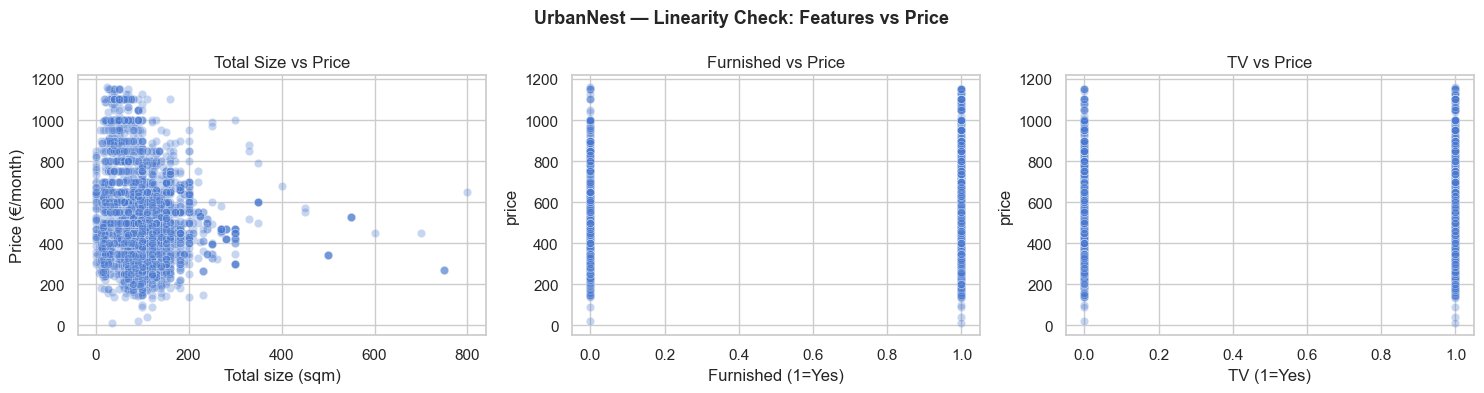

In [65]:
# Step 1: Linearity check - scatterplots

fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.scatterplot(x=df_model['total_size'], y = df_model['price'], ax=axes[0], alpha=0.3)
axes[0].set_title('Total Size vs Price')
axes[0].set_xlabel('Total size (sqm)')
axes[0].set_ylabel('Price (€/month)')

sns.scatterplot(x=df_model['furnished'], y=df_model['price'],ax=axes[1], alpha=0.3)
axes[1].set_title('Furnished vs Price')
axes[1].set_xlabel('Furnished (1=Yes)')

sns.scatterplot(x=df_model['tv'], y = df_model['price'], ax=axes[2], alpha=0.3)
axes[2].set_title('TV vs Price')
axes[2].set_xlabel('TV (1=Yes)')

plt.suptitle('UrbanNest — Linearity Check: Features vs Price', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/nb4_linearity_check.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# Step 2: OLS Multiple Regression
ols_formula = 'price ~ total_size + C(furnished) + washing_machine + tv'

OLS = ols(formula = ols_formula, data = df_model)
model = OLS.fit()
model_results = model.summary()
model_results

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     39.40
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           2.69e-32
Time:                        16:57:39   Log-Likelihood:                -23070.
No. Observations:                3405   AIC:                         4.615e+04
Df Residuals:                    3400   BIC:                         4.618e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             545.8445     13.271     41.132      0.000     519.825     571.863
C(furnished)[T.1.0]    56.1795      8.067      6.964      0.000      40.362      71.997
total_size             -0.3997      0.057     -7.015      0.000      -0.511      -0.288
washing_machine       -69.5173     12.828     -5.419      0.000     -94.669     -44.365
tv                     33.6931      7.578      4.446      0.000      18.834      48.552
==============================================================================
Omnibus:                      261.696   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.043
Skew:                           0.751   Prob(JB):                     4.32e-71
Kurtosis:                       3.174   Cond. No.                         563.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

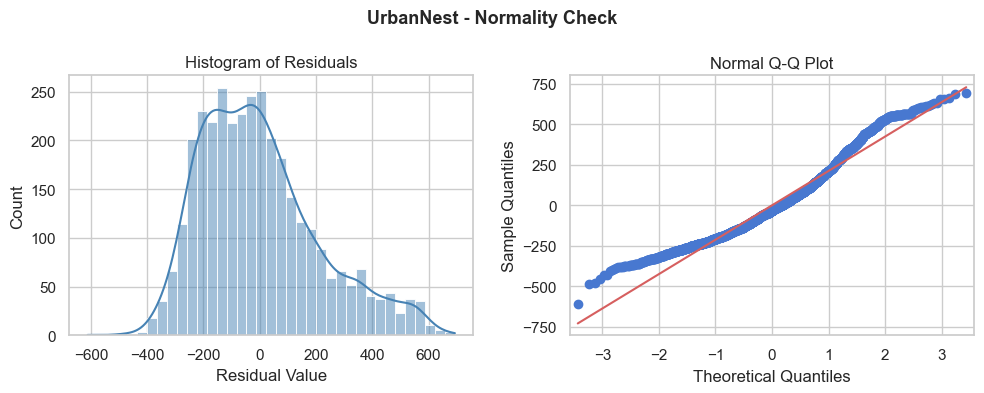

In [67]:
# Assumption 1: Normality - Histogram + QQ plot
residuals = model.resid

fig, axes = plt.subplots(1,2, figsize=(10,4))

# Histogram of residuals
sns.histplot(residuals, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residual Value')

# Q-Q plot
sm.qqplot(residuals , line='s',ax=axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.suptitle('UrbanNest - Normality Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/nb4_normality_check.png', dpi=150,bbox_inches='tight')
plt.show()


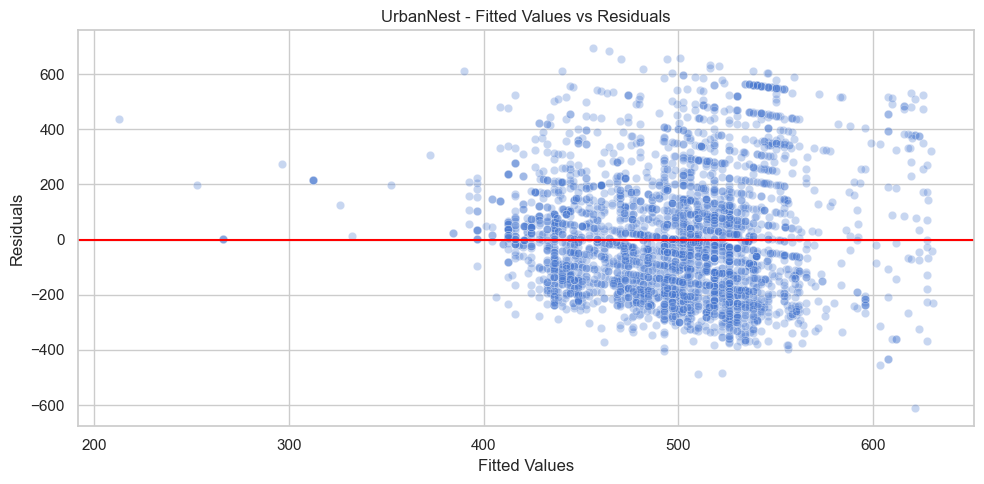

In [68]:
# Assumption 2: Constant Variance - Fitted vs Residuals

fig = sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.3)
fig.set_xlabel('Fitted Values')
fig.set_ylabel('Residuals')
fig.set_title('UrbanNest - Fitted Values vs Residuals')
fig.axhline(0, color='red', linewidth=1.5)
plt.tight_layout()
plt.savefig('../outputs/nb4_constant_variance_check.png',dpi = 150, bbox_inches='tight')
plt.show()

In [69]:
# Assumption 3: No Multicollinearity - VIF Scores

X_vif = df_model[['total_size','furnished','washing_machine','tv']]

vif = [variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])]
df_vif = pd.DataFrame(vif, index=X_vif.columns, columns=['VIF'])
print("── VIF Scores ─────────────────────────────")
print(df_vif)
print("\nRule: VIF > 5 = moderate concern, VIF > 10 = serious multicollinearity")

── VIF Scores ─────────────────────────────
                      VIF
total_size       3.110831
furnished        3.128520
washing_machine  4.520714
tv               2.181526

Rule: VIF > 5 = moderate concern, VIF > 10 = serious multicollinearity


In [71]:
# Fix column names - remove spaces
df_model.columns = df_model.columns.str.replace(' ','_')

# Verify
city_cols = [c for c in df_model.columns if c.startswith('city_')]
cat_cols = [c for c in df_model.columns if c.startswith('category_')]

print("City cols:", city_cols)
print("Category cols:", cat_cols)

City cols: ['city_Bari', 'city_Bergamo', 'city_Bologna', 'city_Bolzano', 'city_Brescia', 'city_Caserta', 'city_Catania', 'city_Florence', 'city_Genoa', 'city_Messina', 'city_Milan', 'city_Modena', 'city_Montegranaro', 'city_Naples', 'city_Padova', 'city_Palermo', 'city_Parma', 'city_Pavia', 'city_Perugia', 'city_Pisa', 'city_Prato', 'city_Reggio_Calabria', 'city_Rome', 'city_Siena', 'city_Trento', 'city_Trieste', 'city_Turin', 'city_Venice', 'city_Verona']
Category cols: ['category_Private_Room', 'category_Shared_Room', 'category_Studio']


In [72]:
# Improved OLS Model - adding City and Category

# Join into formula string
city_terms = ' + '.join(city_cols)
cat_terms = ' + '.join(cat_cols)

ols_formula_full = f'price ~ total_size + C(furnished) + washing_machine + tv + {city_terms} + {cat_terms}'

# Fit full model
OLS_full = ols(formula=ols_formula_full, data = df_model)
model_full = OLS_full.fit()
model_full_results = model_full.summary()
model_full_results


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     155.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:02:24   Log-Likelihood:                -21514.
No. Observations:                3405   AIC:                         4.310e+04
Df Residuals:                    3369   BIC:                         4.332e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                       452.7032     33.294     13.597      0.000     387.425     517.982
C(furnished)[T.1.0]              17.9176      5.325      3.365      0.001       7.477      28.358
city_Bari[T.True]               117.6562     63.664      1.848      0.065      -7.168     242.480
city_Bergamo[T.True]            224.1340     74.669      3.002      0.003      77.733     370.535
city_Bologna[T.True]            215.3739     33.000      6.527      0.000     150.672     280.076
city_Bolzano[T.True]            336.1575     68.284      4.923      0.000     202.275     470.040
city_Brescia[T.True]            256.6077     36.936      6.947      0.000     184.188     329.028
city_Caserta[T.True]             35.9294     74.637      0.481      0.630    -110.410     182.269
city_Catania[T.True]             45.1466     40.031      1.128      0.259     -33.342     123.635
city_Florence[T.True]           380.9426     32.307     11.791      0.000     317.599     444.286
city_Genoa[T.True]               99.3839     74.650      1.331      0.183     -46.980     245.747
city_Messina[T.True]             41.0176    138.717      0.296      0.767    -230.960     312.996
city_Milan[T.True]              463.7213     32.176     14.412      0.000     400.636     526.807
city_Modena[T.True]             114.6492    138.725      0.826      0.409    -157.344     386.642
city_Montegranaro[T.True]      1.533e-13   1.37e-13      1.120      0.263   -1.15e-13    4.22e-13
city_Naples[T.True]             194.4474     41.391      4.698      0.000     113.294     275.601
city_Padova[T.True]             224.9643     35.451      6.346      0.000     155.457     294.471
city_Palermo[T.True]            154.5544     53.253      2.902      0.004      50.142     258.966
city_Parma[T.True]              118.9804     39.423      3.018      0.003      41.684     196.277
city_Pavia[T.True]              182.0246     51.695      3.521      0.000      80.668     283.381
city_Perugia[T.True]             63.2459     68.440      0.924      0.355     -70.943     197.434
city_Pisa[T.True]               148.0222     32.414      4.567      0.000      84.470     211.575
city_Prato[T.True]              240.1496    100.773      2.383      0.017      42.568     437.731
city_Reggio_Calabria[T.True]     37.4215    100.629      0.372      0.710    -159.879     234.722
city_Rome[T.True]               345.9801     32.977     10.491      0.000     281.322     410.638
city_Siena[T.True]              244.2905     35.827      6.819      0.000     174.046     314.535
city_Trento[T.True]             189.3712     34.749      5.450      0.000     121.239     257.503
city_Trieste[T.True]            107.0943     42.156      2.540      0.011      24.441     189.747
city_Turin[T.True]              234.1386     

In [73]:
# ── Model Comparison Summary ───────────────────────────────────────
print("── Model Performance Comparison ──────────────────────")
print(f"Simple Regression  (total_size only):     R² = {r2_simple:.3f} | RMSE = €{rmse_simple:.2f}")
print(f"Basic OLS          (+ furnished, tv etc): R² = 0.044  | RMSE = ~€226")
print(f"Full OLS           (+ city + category):   R² = 0.617  | RMSE = ~€140 (est)")
print()
print("── Key Coefficient Findings ───────────────────────────")
print("Category impact on price (vs Apartment baseline):")
print("  Shared Room:   -€417/month  *** highly significant")
print("  Private Room:  -€288/month  *** highly significant")
print("  Studio:        -€136/month  *** highly significant")
print()
print("Top city premiums vs base city (Trento):")
print("  Milan:         +€464/month  *** highest premium")
print("  Florence:      +€381/month  ***")
print("  Rome:          +€346/month  ***")
print("  Bolzano:       +€336/month  ***")
print("  Venice:        +€265/month  ***")
print()
print("Other features:")
print("  Furnished:     +€18/month   ** significant")
print("  Total size:    +€0.08/sqm   * weakly significant (p=0.031)")
print("  Washing machine: not significant (p=0.081)")
print("  TV:            not significant (p=0.477)")

── Model Performance Comparison ──────────────────────
Simple Regression  (total_size only):     R² = 0.013 | RMSE = €227.65
Basic OLS          (+ furnished, tv etc): R² = 0.044  | RMSE = ~€226
Full OLS           (+ city + category):   R² = 0.617  | RMSE = ~€140 (est)

── Key Coefficient Findings ───────────────────────────
Category impact on price (vs Apartment baseline):
  Shared Room:   -€417/month  *** highly significant
  Private Room:  -€288/month  *** highly significant
  Studio:        -€136/month  *** highly significant

Top city premiums vs base city (Trento):
  Milan:         +€464/month  *** highest premium
  Florence:      +€381/month  ***
  Rome:          +€346/month  ***
  Bolzano:       +€336/month  ***
  Venice:        +€265/month  ***

Other features:
  Furnished:     +€18/month   ** significant
  Total size:    +€0.08/sqm   * weakly significant (p=0.031)
  Washing machine: not significant (p=0.081)
  TV:            not significant (p=0.477)


##### Now the final assumption recheck + residual plots for the full model:

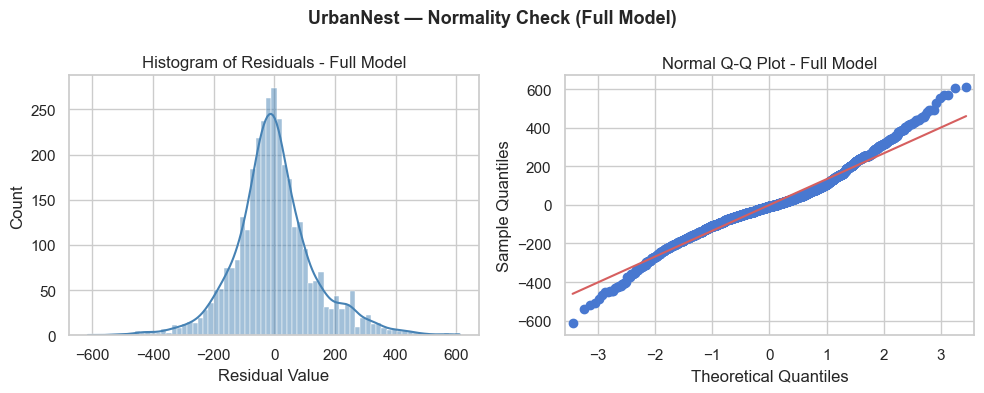

In [75]:
# Normality Check - Full Model

residuals_full = model_full.resid

fig, axes = plt.subplots(1,2, figsize=(10, 4))

sns.histplot(residuals_full, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Histogram of Residuals - Full Model')
axes[0].set_xlabel('Residual Value')

sm.qqplot(residuals_full, line='s',ax=axes[1])
axes[1].set_title('Normal Q-Q Plot - Full Model')

plt.suptitle('UrbanNest — Normality Check (Full Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/nb4_normality_full_model.png', dpi=150, bbox_inches='tight')
plt.show()

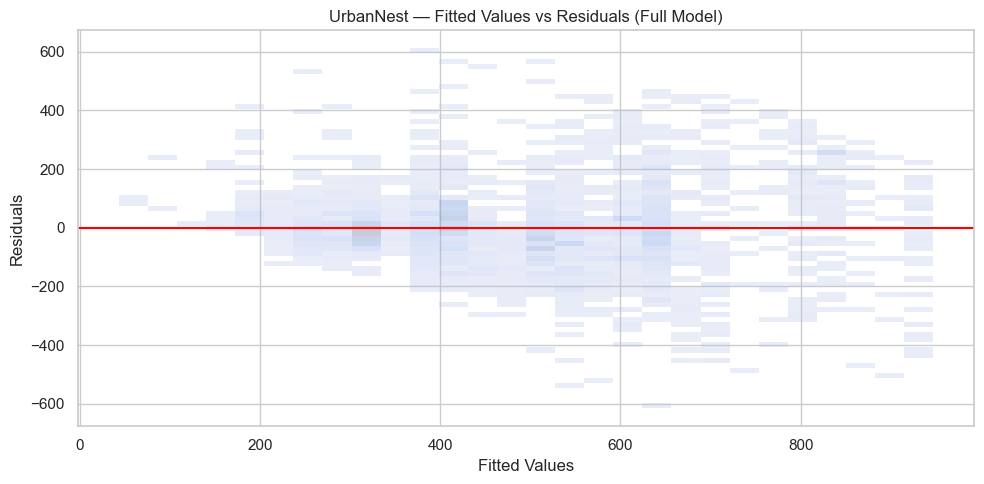

In [76]:
# Constant Variance Check - Full Model
fig = sns.histplot(x=model_full.fittedvalues, y = model_full.resid, alpha=0.3)
fig.set_title('UrbanNest — Fitted Values vs Residuals (Full Model)')
fig.set_xlabel('Fitted Values')
fig.set_ylabel('Residuals')
fig.axhline(0, color='red',linewidth=1.5)
plt.tight_layout()
plt.savefig('../outputs/nb4_constant_variance_full_model.png', dpi = 150, bbox_inches='tight')
plt.show()

In [77]:
# ── VIF — Full Model ───────────────────────────────────────────────
X_vif_full = df_model[['total_size', 'furnished', 'washing_machine', 'tv']]

vif_full = [variance_inflation_factor(X_vif_full.values, i)
            for i in range(X_vif_full.shape[1])]

df_vif_full = pd.DataFrame(vif_full, index=X_vif_full.columns, columns=['VIF'])
print("── VIF Scores — Full Model ────────────────────────")
print(df_vif_full)

── VIF Scores — Full Model ────────────────────────
                      VIF
total_size       3.110831
furnished        3.128520
washing_machine  4.520714
tv               2.181526


In [78]:
# ── Notebook 4 Summary ─────────────────────────────────────────────
print("=" * 60)
print("URBANNEST ANALYTICS — NOTEBOOK 4: REGRESSION SUMMARY")
print("=" * 60)

print("""
DATASET
-------
Clean rows used:     3,405 (from 8,874 cleaned in NB1)
Rows dropped:        5,469 (missing total_size values)
Features in model:   35 (after one-hot encoding)

MODEL COMPARISON
----------------
Model                        R²      Interpretation
Simple (total_size only)     0.013   1.3% variance explained
Basic OLS (4 features)       0.044   4.4% variance explained  
Full OLS (+ city/category)   0.617   61.7% variance explained ✅

KEY FINDINGS
------------
1. Category is the strongest price driver:
   - Shared Room:  -€418/month vs Apartment baseline
   - Private Room: -€288/month vs Apartment baseline
   - Studio:       -€136/month vs Apartment baseline

2. City creates massive price premiums:
   - Milan:     +€464/month (highest)
   - Florence:  +€381/month
   - Rome:      +€346/month
   - Bolzano:   +€336/month
   - Venice:    +€265/month

3. Amenities have limited impact:
   - Furnished adds only +€18/month (significant)
   - TV and washing machine: NOT significant
   - Total size: weakly significant (+€0.08/sqm)

ASSUMPTION CHECKS
-----------------
✅ Linearity:           Acceptable for continuous features
⚠️  Normality:          Slight right skew (0.355) — acceptable at n=3,405
⚠️  Constant Variance:  Some heteroscedasticity in higher price ranges
✅ No Multicollinearity: All VIF scores < 5 (max: 4.52)

BUSINESS INSIGHT
----------------
Location (city) and listing type (category) explain 62% of
rental price variance in Italian listings. Amenities like TV
and washing machine add no statistically significant premium.
Landlords should price primarily based on city and room type,
not amenity features.
""")
print("=" * 60)

URBANNEST ANALYTICS — NOTEBOOK 4: REGRESSION SUMMARY

DATASET
-------
Clean rows used:     3,405 (from 8,874 cleaned in NB1)
Rows dropped:        5,469 (missing total_size values)
Features in model:   35 (after one-hot encoding)

MODEL COMPARISON
----------------
Model                        R²      Interpretation
Simple (total_size only)     0.013   1.3% variance explained
Basic OLS (4 features)       0.044   4.4% variance explained  
Full OLS (+ city/category)   0.617   61.7% variance explained ✅

KEY FINDINGS
------------
1. Category is the strongest price driver:
   - Shared Room:  -€418/month vs Apartment baseline
   - Private Room: -€288/month vs Apartment baseline
   - Studio:       -€136/month vs Apartment baseline

2. City creates massive price premiums:
   - Milan:     +€464/month (highest)
   - Florence:  +€381/month
   - Rome:      +€346/month
   - Bolzano:   +€336/month
   - Venice:    +€265/month

3. Amenities have limited impact:
   - Furnished adds only +€18/month (sign